# `spiess` — Spiess's (1990) count-misfit-only OD estimation

**What.** `spiess` (T2, ADR-002) drops the prior term entirely below full
weight and instead solves a bilevel program: an inner MSA route-choice
assignment feeding an outer count-misfit gradient step on the OD matrix,
guarded by a retrospective Armijo step-size search over the observed-count
RMSE. Unlike `gls`, it has no closed form — every claim below is the
estimator's ACTUAL trajectory, certified against the harness pin.

**Why it is in the benchmark.** It is the count-driven end of the T2
spectrum (vs `gls`'s balanced prior/count trade-off), and it exposes a real
methodological trap: on Braess, the count-misfit objective has a SPURIOUS
local minimum that a naive gradient descent from a plausible prior falls
into. ADR-002 Decision 3's retrospective-Armijo + best-self-obs-RMSE
safeguard exists specifically to refuse that trap — this notebook makes both
the trap and the safeguard executable facts, not narrative. See the
[model compendium](../../docs/MODELS.md) (Spiess 1990) and
[docs/design/adr-002-t2-estimation-certificate.md](../../docs/design/adr-002-t2-estimation-certificate.md)
(P1, Decision 3).

**Scope.** Two-route convex sanity recovery, Braess global-basin recovery
from `D=5.5`, and the Braess `D=4`-prior local-minimum trap + safeguard —
all certified in-cell.

**Canon.** `[spiess1990gradient]`, [docs/REFERENCES.md](../../docs/REFERENCES.md) / [docs/references.bib](../../docs/references.bib).

## How this notebook is graded

**A notebook never claims a number it does not compute in that cell.** Every
scored quantity below is recomputed live by the P1 `ODCertifier` from the
emitted OD matrix against the harness's own pinned BFW assignment of the
truth — never from `spiess`'s self-reported inner-MSA proportions
([README](../../README.md), *Certified, not self-reported*).

In [1]:
# Setup. `spiess` is a core estimator: a plain `pip install -e .` suffices —
# no optional extra, so no guard cell. The inline backend is Agg-based
# (headless CI renders into the notebook); NEVER matplotlib.use("Agg")
# in-kernel — it silently suppresses inline figure capture.
%matplotlib inline
import numpy as np

from tabench import (
    Budget,
    Demand,
    ODCertifier,
    RngBundle,
    SpiessEstimator,
    Trace,
    braess_scenario,
    two_route_scenario,
    viz,
)
from tabench.core.rng import SOURCE_OBSERVATION
from tabench.estimation import ODTrace
from tabench.estimation.base import EstimationTask
from tabench.models.frank_wolfe import BiconjugateFrankWolfeModel
from tabench.observe.levels import LinkCounts

BRAESS_TRUTH = np.array([4.0, 2.0, 2.0, 2.0, 4.0])  # UE(D=6), recomputed below
TWOROUTE_TRUTH = np.array([2.5, 2.5, 1.5, 1.5])  # UE(D=4), recomputed below

# Analytic anchors recomputed, never quoted: pin both by an independent
# high-precision BFW solve before EITHER constant is used as a data-generating
# truth anywhere below.
def _pinned_ue(scenario):
    trace = Trace()
    BiconjugateFrankWolfeModel().solve(
        scenario, Budget(iterations=5000, target_relative_gap=1e-10), RngBundle(0), trace
    )
    return trace.final.link_flows

np.testing.assert_allclose(_pinned_ue(braess_scenario(6.0)), BRAESS_TRUTH, atol=1e-6)
np.testing.assert_allclose(_pinned_ue(two_route_scenario(sue_theta=None)), TWOROUTE_TRUTH, atol=1e-6)


def _single_pair_prior(d):
    m = np.zeros((2, 2))
    m[0, 1] = d
    return m


def _task(scenario, truth, sensors, prior_matrix):
    ds = LinkCounts(np.asarray(sensors), 1, "none").observe(
        scenario, truth, RngBundle(0).generator(SOURCE_OBSERVATION)
    )
    return EstimationTask(
        name="t", network=scenario.network, prior=Demand(np.asarray(prior_matrix, dtype=np.float64)),
        dataset=ds, identifiability={}, scenario_hash=scenario.content_hash(), seed=0,
    )

## Sanity: two-route convex recovery

On the convex two-route corridor (a single OD pair, no spurious minima),
`spiess` recovers the true `D=4` from an off prior `D=3` under full sensors.

In [2]:
sc2 = two_route_scenario(sue_theta=None)
task2 = _task(sc2, TWOROUTE_TRUTH, np.arange(4), _single_pair_prior(3.0))
trace2 = ODTrace()
SpiessEstimator(k_inner=120, outer_iters=80).estimate(
    task2, Budget(sp_calls=10**9, iterations=200), RngBundle(0), trace2
)
print(f"recovered D : {trace2.final.od_matrix[0, 1]:.4f}  (truth: 4.0, off prior: 3.0)")
assert abs(trace2.final.od_matrix[0, 1] - 4.0) < 1e-3

recovered D : 4.0000  (truth: 4.0, off prior: 3.0)


## Braess: global-basin recovery from `D=5.5`

`braess_scenario(6.0)` is the D=6 Braess network, frozen and content-hashed
(P2). From a prior `D=5.5` — inside the count-misfit objective's GLOBAL
basin — full noiseless sensors let `spiess` recover the true `D=6`.

In [3]:
sc = braess_scenario(6.0)
print(f"scenario      : {sc.name}")
print(f"content hash  : {sc.content_hash()[:16]}…")

task_global = _task(sc, BRAESS_TRUTH, np.arange(5), _single_pair_prior(5.5))
trace_global = ODTrace()
SpiessEstimator(k_inner=120, outer_iters=80).estimate(
    task_global, Budget(sp_calls=10**9, iterations=200), RngBundle(0), trace_global
)
recovered = trace_global.final.od_matrix[0, 1]
print(f"recovered D : {recovered:.4f}  (truth: 6.0, off prior: 5.5)")
assert abs(recovered - 6.0) < 1e-3

certifier = ODCertifier(
    sc, np.arange(5), np.array([], dtype=np.int64),
    BRAESS_TRUTH[None, :], BRAESS_TRUTH[[]][None, :], BRAESS_TRUTH,
    {"linear_identifiable": True},
)
metrics = certifier.certify(trace_global.final.od_matrix)
print(f"certified od_rmse : {metrics['od_rmse']:.4e}")
assert metrics["od_feasible"] == 1.0
assert metrics["od_rmse"] < 1e-3

scenario      : braess
content hash  : cf00f411cdccec88…


recovered D : 6.0000  (truth: 6.0, off prior: 5.5)
certified od_rmse : 0.0000e+00


## The distinctive result: the `D=4`-prior spurious local minimum

The SAME Braess network's count-misfit objective has a SECOND, dominated
stationary point near `D=10/3` (the bypass-saturated regime: outer links
`1->4` and `3->2` carry zero flow at `D=10/3`, giving flows `(10/3, 0, 10/3,
0, 10/3)`, whose count RMSE against the truth is strictly worse than the
prior's own RMSE). From a prior `D=4` — inside that trap's basin — a naive
gradient descent would fall in; ADR-002 Decision 3's retrospective-Armijo +
best-self-obs-RMSE safeguard REFUSES the trap: the emitted estimate is
neither the global optimum `D=6` NOR the dominated trap `D=10/3`.

In [4]:
task_trap = _task(sc, BRAESS_TRUTH, np.arange(5), _single_pair_prior(4.0))
trace_trap = ODTrace()
SpiessEstimator(k_inner=120, outer_iters=120).estimate(
    task_trap, Budget(sp_calls=10**9, iterations=120), RngBundle(0), trace_trap
)
g = trace_trap.final.od_matrix[0, 1]
print(f"emitted D : {g:.4f}  (NOT 6.0, NOT 10/3={10/3:.4f})")
assert abs(g - 6.0) > 1.0  # emphatically not the global optimum
assert abs(g - 10.0 / 3.0) > 0.25  # and NOT the dominated 10/3 trap either

# The safeguard held: the returned self obs-RMSE beats the trap's own RMSE,
# where the bypass carries all demand (flows (10/3, 0, 10/3, 0, 10/3)).
trap_flows = np.array([10.0 / 3.0, 0.0, 10.0 / 3.0, 0.0, 10.0 / 3.0])
trap_resid = float(np.sqrt(np.mean((trap_flows - BRAESS_TRUTH) ** 2)))
emitted_resid = trace_trap.final.self_report["obs_count_rmse"]
print(f"emitted self obs_count_rmse (provenance only) : {emitted_resid:.4f}")
print(f"dominated-trap obs_count_rmse                 : {trap_resid:.4f}")
assert emitted_resid < trap_resid

# The self-report comparison above, RE-CERTIFIED (P1): the trap itself is the
# D=10/3 OD matrix (same certifier object built for the global-basin recovery
# above), so both sides of the safeguard claim are independently harness-scored,
# not read from the estimator's own bookkeeping.
certified_emitted = certifier.certify(trace_trap.final.od_matrix)["obs_count_rmse"]
certified_trap = certifier.certify(_single_pair_prior(10.0 / 3.0))["obs_count_rmse"]
print(f"certified emitted obs_count_rmse : {certified_emitted:.4f}")
print(f"certified trap obs_count_rmse    : {certified_trap:.4f}")
assert certified_emitted < certified_trap
# Self-report tracks the certificate closely for this white box (honesty diff).
assert np.isclose(emitted_resid, certified_emitted, atol=0.05)

emitted D : 3.9967  (NOT 6.0, NOT 10/3=3.3333)
emitted self obs_count_rmse (provenance only) : 1.2292
dominated-trap obs_count_rmse                 : 1.4606
certified emitted obs_count_rmse : 1.2538
certified trap obs_count_rmse    : 1.4606


## Visualize

`tabench.viz` draws the road `Network`'s link flows — the trap's dominated
flow pattern vs the truth, both certifiable quantities from the cells above.

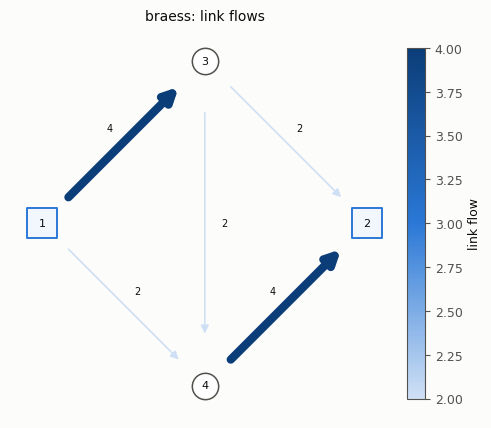

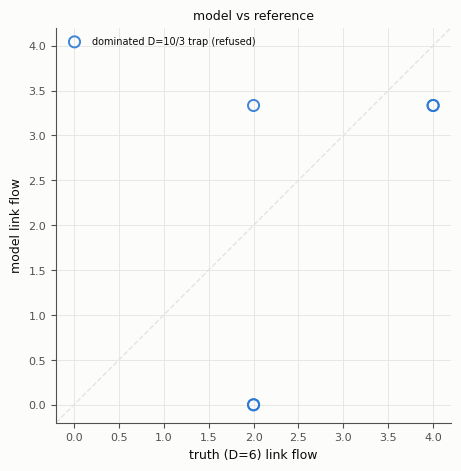

In [5]:
display(viz.plot_network_flows(sc.network, BRAESS_TRUTH))
display(viz.plot_flow_scatter(
    ("truth (D=6)", BRAESS_TRUTH),
    {"dominated D=10/3 trap (refused)": trap_flows},
))

## Takeaways & pointers

- **Certified, not self-reported.** Every `od_rmse` above came from
  `ODCertifier`'s own re-assignment of the emitted OD matrix, never from
  `spiess`'s inner-MSA proportions.
- **The safeguard is load-bearing, not decorative.** From `D=4`, an
  unguarded gradient descent would land at the dominated `D=10/3` trap;
  ADR-002 Decision 3's retrospective-Armijo + best-self-obs-RMSE check
  refuses it, verified above as an executable fact.
- **Where next.** the balanced-tradeoff sibling on the SAME network
  [`gls`](01-gls.ipynb) (recovers from the SAME `D=5.5` global-basin prior);
  the entropy-balancing alternative [`vzw-entropy`](03-vzw-entropy.ipynb);
  the lineage in the [model compendium](../../docs/MODELS.md).